# 04 · EDA — 03. Análisis de variables categóricas

Tercer notebook del análisis exploratorio. Se centra en las **variables categóricas y de baja cardinalidad**
del dataset, estudiando tanto su distribución univariada como su relación con el salario (`log(gross_annual_eur)`).

## Bloques abordados

1. **Posición** (`position`): distribución y relación con el salario.
2. **Edad** (`age`): tratada como variable categórica agrupada en bins.
3. **Curva edad-salario**: análisis de la forma de campana clásica en economía laboral.
4. **Cruce posición × edad**: cómo varía el salario según el ciclo de carrera por posición.
5. **Nacionalidad**: análisis del top de nacionalidades y su relación con el salario.
6. **Resumen y conclusiones** para feature engineering.

⚠️ Todos los análisis con salario se hacen sobre `log(gross_annual_eur)`, conforme a la decisión
metodológica del notebook 04_02.

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT  = Path.cwd().parents[1]
CLEAN = ROOT / 'data' / 'clean' / 'master_clean.csv'

df = pd.read_csv(CLEAN, dtype={'season': str})

# Subset con salario para análisis log
df_sal = df.dropna(subset=['gross_annual_eur']).copy()
df_sal['log_sal'] = np.log(df_sal['gross_annual_eur'])

print(f'Dataset cargado: {len(df):,} filas')
print(f'Con salario:     {len(df_sal):,} ({len(df_sal)/len(df)*100:.1f}%)')

Dataset cargado: 20,307 filas
Con salario:     18,463 (90.9%)


## 2. Variable `position`

La columna `position` clasifica a cada jugador en una de cuatro categorías:

| Código | Significado |
|---|---|
| `K` | Goalkeeper (portero) |
| `D` | Defender (defensa) |
| `M` | Midfielder (centrocampista) |
| `F` | Forward (delantero) |

### 2.1 Distribución de jugadores por posición

=== Recuento por posición ===
position
F      6520
D      6355
M      4183
NaN    1756
K      1493
Name: count, dtype: int64

Nulos en position: 1,756 (8.6%)


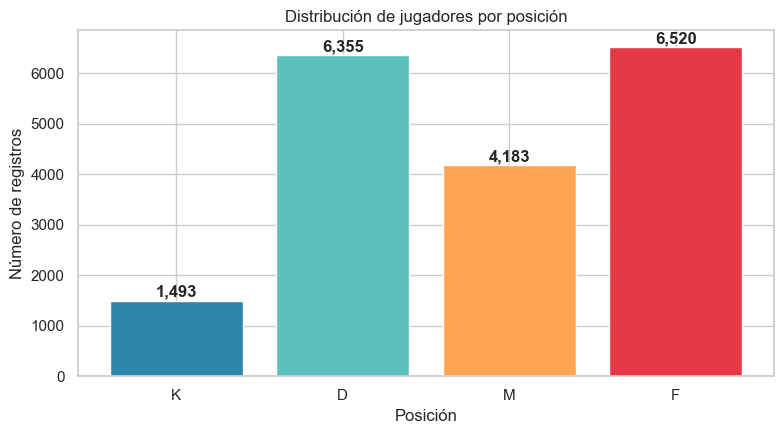

In [2]:
orden_pos = ['K', 'D', 'M', 'F']
counts = df['position'].value_counts(dropna=False)

print('=== Recuento por posición ===')
print(counts)
print(f'\nNulos en position: {df["position"].isna().sum():,} ({df["position"].isna().mean()*100:.1f}%)')

# Para el gráfico, solo las posiciones válidas en el orden definido
counts_plot = counts.reindex(orden_pos)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#2E86AB', '#5BC0BE', '#FFA552', '#E63946']
ax.bar(counts_plot.index.tolist(), counts_plot.values, color=colors, edgecolor='white')
ax.set_xlabel('Posición')
ax.set_ylabel('Número de registros')
ax.set_title('Distribución de jugadores por posición')
for i, v in enumerate(counts_plot.values):
    ax.text(i, v + 80, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura:** la distribución refleja la composición típica de las plantillas de fútbol, donde
predominan defensas y delanteros sobre centrocampistas, y los porteros son la minoría (3-4 por equipo
de plantilla).

### 2.2 Salario por posición

In [3]:
# Estadísticos de salario por posición
stats_pos = (
    df_sal.groupby('position')['gross_annual_eur']
    .agg(['count', 'median', 'mean'])
    .round(0)
    .reindex(orden_pos)
)
stats_pos['median'] = stats_pos['median'].apply(lambda x: f'{x:,.0f}€')
stats_pos['mean']   = stats_pos['mean'].apply(lambda x: f'{x:,.0f}€')
display(stats_pos)

,count,median,mean
position,,,
K,1489,"903,608€","1,928,233€"
D,6328,"1,040,000€","1,997,919€"
M,4161,"1,200,000€","2,199,789€"
F,6485,"1,130,000€","2,440,706€"


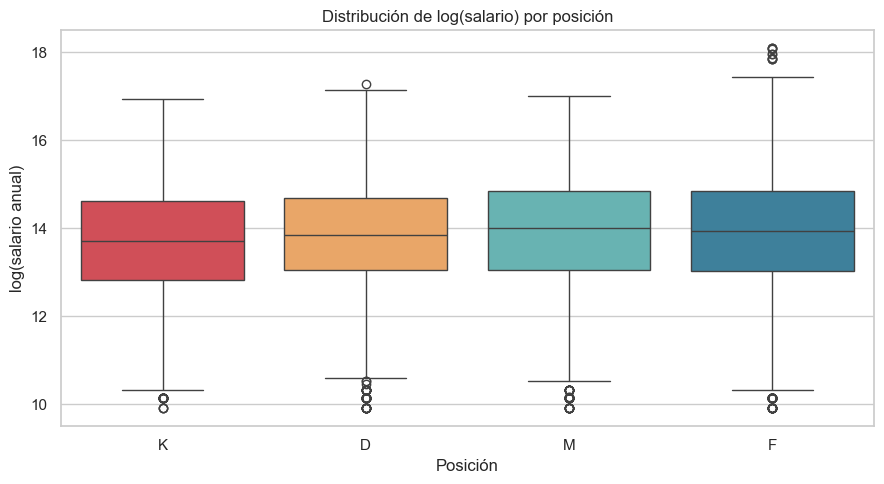

In [4]:
# Boxplot de log(salario) por posición
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_sal, x='position', y='log_sal',
            hue='position', order=orden_pos, palette=colors, legend=False, ax=ax)
ax.set_xlabel('Posición')
ax.set_ylabel('log(salario anual)')
ax.set_title('Distribución de log(salario) por posición')
plt.tight_layout()
plt.show()

**Hallazgo importante:** los **porteros** son la posición peor remunerada en mediana, a pesar de ser
una posición clave. Los **delanteros y centrocampistas** se sitúan en la parte alta. Esto es coherente
con el "premio" salarial al que aporta goles y creación, donde la cuantificación del rendimiento es más
directa.

**Implicación para el modelado:** la posición es una variable explicativa muy relevante. Más aún,
**las stats útiles para predecir salario son distintas por posición**: para un portero, `goalsPrevented`
y `savesAccuracy`; para un delantero, `goals` y `expectedGoals`. Esto motiva la consideración de
**modelos separados por posición** en la fase 06.

## 3. Variable `age`

La edad es matemáticamente una variable numérica continua, pero su efecto sobre el salario es
**altamente no lineal**: existe una curva de carrera con fase de crecimiento, plateau y declive.
Por eso conviene también analizarla agrupada en bins.

### 3.1 Distribución de edades

=== Estadísticos de edad ===
count    18551.0
mean        26.1
std          4.5
min         15.0
25%         23.0
50%         26.0
75%         29.0
max         43.0
Name: age, dtype: float64


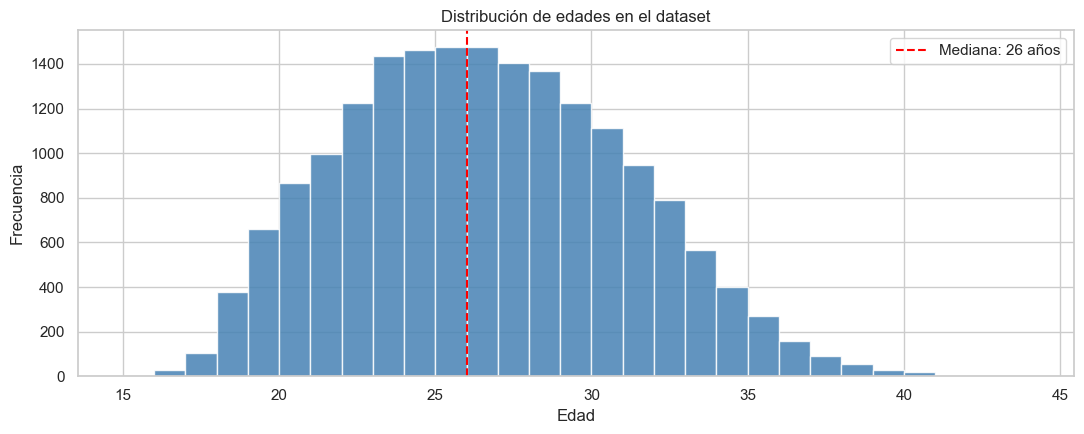

In [5]:
print('=== Estadísticos de edad ===')
print(df['age'].describe().round(1))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(df['age'].dropna(), bins=range(15, 45), color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de edades en el dataset')
ax.axvline(df['age'].median(), color='red', linestyle='--', label=f'Mediana: {df["age"].median():.0f} años')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Edad agrupada en bins

In [6]:
edad_bins   = [15, 20, 23, 26, 29, 32, 35, 45]
edad_labels = ['<20', '20-22', '23-25', '26-28', '29-31', '32-34', '35+']

df_sal['edad_grupo'] = pd.cut(df_sal['age'], bins=edad_bins, labels=edad_labels, right=False)
df['edad_grupo']     = pd.cut(df['age'],     bins=edad_bins, labels=edad_labels, right=False)

counts_edad = df['edad_grupo'].value_counts().sort_index()
print('=== Distribución por grupo de edad ===')
print(counts_edad)

=== Distribución por grupo de edad ===
edad_grupo
<20      1172
20-22    3087
23-25    4373
26-28    4250
29-31    3286
32-34    1751
35+       632
Name: count, dtype: int64


### 3.3 Curva edad-salario

Análisis crítico: ¿se observa la **curva de carrera** característica de los mercados laborales,
con pico salarial en torno a los 28-30 años?

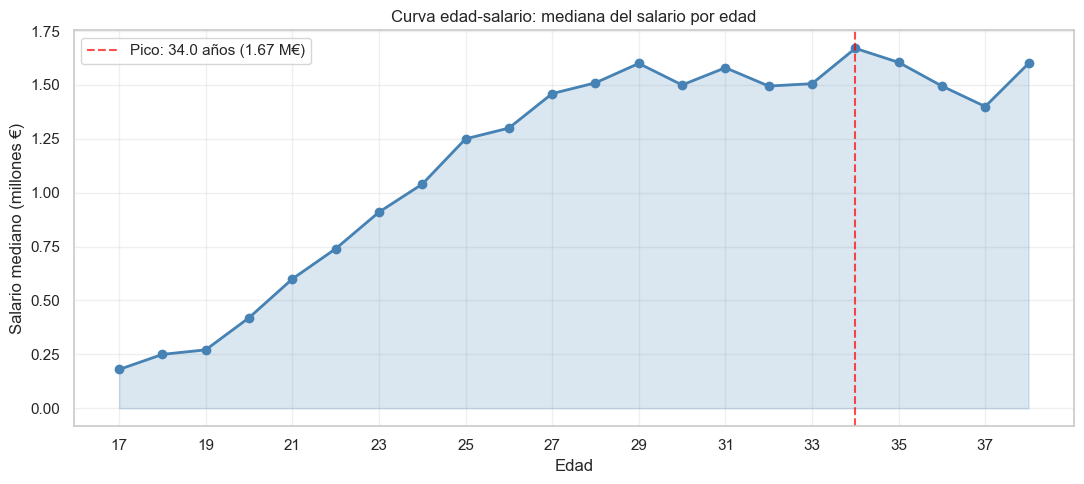

In [7]:
# Mediana del salario por edad (numérica, no agrupada)
medianas_edad = df_sal.groupby('age')['gross_annual_eur'].median() / 1e6
n_por_edad    = df_sal.groupby('age').size()

# Filtramos edades con muestras pequeñas (< 30 jugadores) para evitar ruido
edades_validas = n_por_edad[n_por_edad >= 30].index
medianas_edad_filt = medianas_edad.loc[edades_validas]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(medianas_edad_filt.index, medianas_edad_filt.values, marker='o', lw=2, color='steelblue')
ax.fill_between(medianas_edad_filt.index, medianas_edad_filt.values, alpha=0.2, color='steelblue')
ax.set_xlabel('Edad')
ax.set_ylabel('Salario mediano (millones €)')
ax.set_title('Curva edad-salario: mediana del salario por edad')
ax.set_xticks(range(int(medianas_edad_filt.index.min()),
                    int(medianas_edad_filt.index.max())+1, 2))

# Marcar el pico
edad_pico = medianas_edad_filt.idxmax()
salario_pico = medianas_edad_filt.max()
ax.axvline(edad_pico, color='red', linestyle='--', alpha=0.7,
           label=f'Pico: {edad_pico} años ({salario_pico:.2f} M€)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del gráfico:** se observa una curva con la forma esperada en un mercado laboral profesional:

- **Fase de crecimiento (15–28 años):** el salario crece monotónicamente con la experiencia y madurez deportiva.
- **Plateau (28–32 años):** los jugadores alcanzan su pico de remuneración.
- **Declive (32+ años):** caída progresiva del salario, salvo casos puntuales (Modrić, Pepe...).

Esto es la versión futbolística de la **ecuación de Mincer** (1974), modelo fundacional de la economía
laboral, que postula que `log(salario) ~ educación + experiencia + experiencia²`. La forma de campana
viene del término cuadrático de la experiencia.

### 3.4 Boxplot por grupo de edad

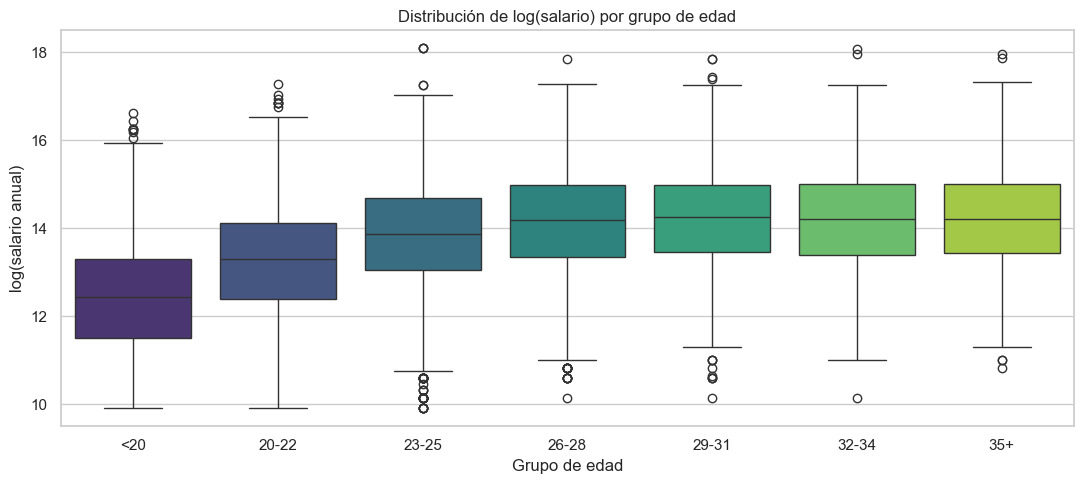

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_sal, x='edad_grupo', y='log_sal', hue='edad_grupo',
            order=edad_labels, palette='viridis', legend=False, ax=ax)
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('log(salario anual)')
ax.set_title('Distribución de log(salario) por grupo de edad')
plt.tight_layout()
plt.show()

## 4. Cruce posición × edad

¿La curva edad-salario es igual para todas las posiciones? La intuición dice que no: los porteros
suelen tener carreras más largas, los delanteros pierden valor antes.

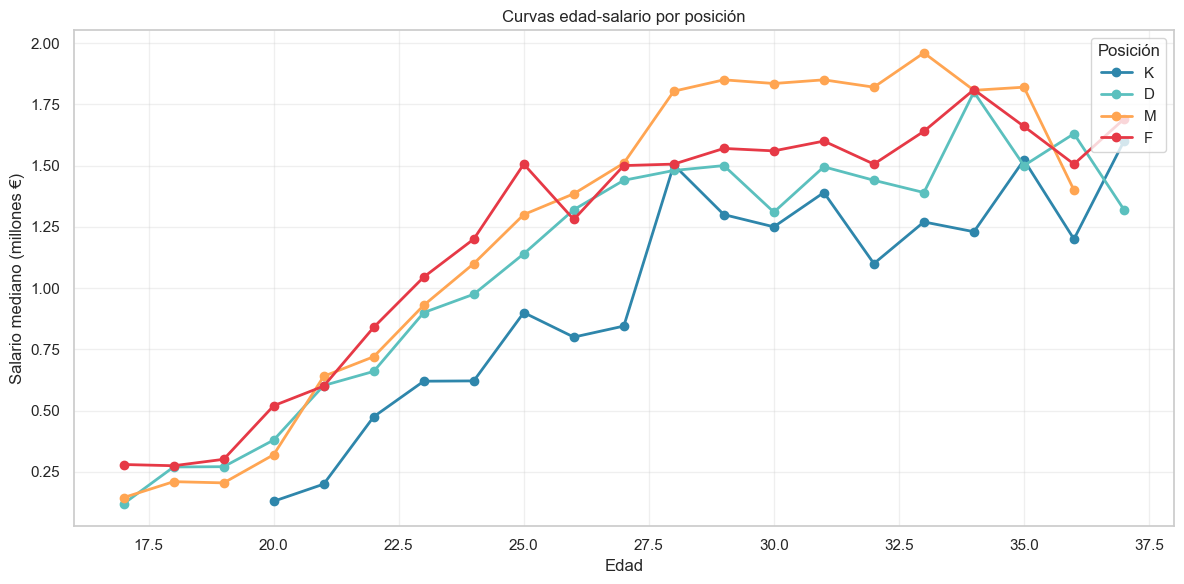

In [9]:
# Curvas edad-salario por posición
fig, ax = plt.subplots(figsize=(12, 6))
colors_pos = {'K': '#2E86AB', 'D': '#5BC0BE', 'M': '#FFA552', 'F': '#E63946'}

for pos in orden_pos:
    sub = df_sal[df_sal['position'] == pos]
    medianas = sub.groupby('age')['gross_annual_eur'].median() / 1e6
    n_por_edad_pos = sub.groupby('age').size()
    edades_validas_pos = n_por_edad_pos[n_por_edad_pos >= 20].index
    medianas_filt = medianas.loc[edades_validas_pos]
    ax.plot(medianas_filt.index, medianas_filt.values,
            marker='o', lw=2, color=colors_pos[pos], label=f'{pos}')

ax.set_xlabel('Edad')
ax.set_ylabel('Salario mediano (millones €)')
ax.set_title('Curvas edad-salario por posición')
ax.legend(title='Posición', loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

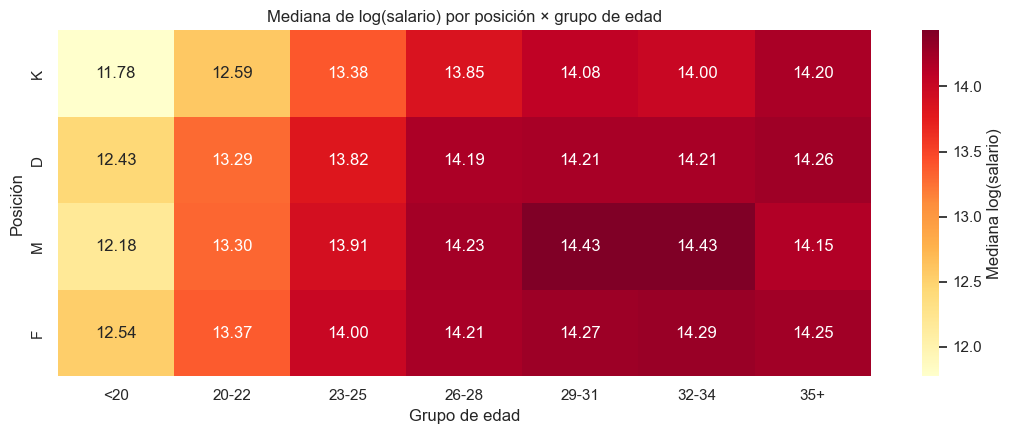

In [10]:
# Heatmap: mediana de log(salario) por posición × grupo edad
heatmap = df_sal.groupby(['position', 'edad_grupo'], observed=True)['log_sal'].median().unstack()
heatmap = heatmap.reindex(orden_pos)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(heatmap, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Mediana log(salario)'}, ax=ax)
ax.set_title('Mediana de log(salario) por posición × grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Posición')
plt.tight_layout()
plt.show()

**Hallazgos:** las trayectorias salariales son **claramente diferentes** entre posiciones, lo que
refuerza la idea metodológica de modelar por separado o usar interacciones `posición × edad` como features.

## 5. Variable `nationality`

El dataset incluye 131 nacionalidades distintas, lo que la convierte en una variable de **alta
cardinalidad**. Aplicarla directamente como categórica generaría una explosión de columnas en
encoding *one-hot*. Estrategia: analizarla agrupada y decidir cómo simplificarla.

### 5.1 Top nacionalidades

Total nacionalidades distintas: 131
Top 10 nacionalidades acumulan: 62.4% de los registros


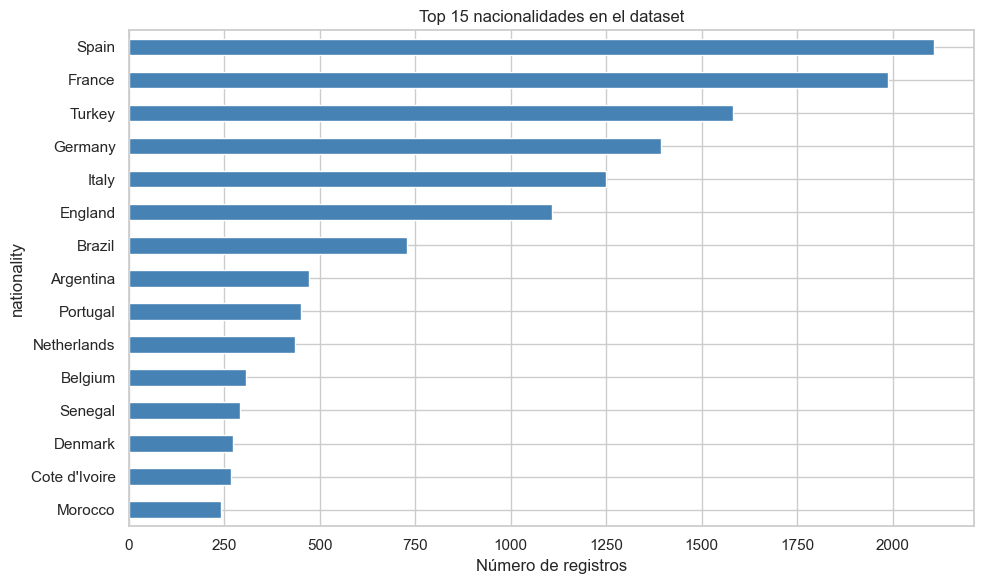

In [11]:
top_nac = df_sal['nationality'].value_counts().head(15)
print(f'Total nacionalidades distintas: {df_sal["nationality"].nunique()}')
print(f'Top 10 nacionalidades acumulan: {df_sal["nationality"].value_counts().head(10).sum()/len(df_sal)*100:.1f}% de los registros')

fig, ax = plt.subplots(figsize=(10, 6))
top_nac.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Número de registros')
ax.set_title('Top 15 nacionalidades en el dataset')
plt.tight_layout()
plt.show()

**Observación:** las **primeras 6 nacionalidades coinciden exactamente con las 6 ligas estudiadas**
(España, Francia, Turquía, Alemania, Italia, Inglaterra), reflejando la **preferencia por jugadores
locales** en cada liga: una proporción muy elevada de los jugadores son nacionales del país donde compiten.

A partir del top 6, aparecen las grandes "potencias exportadoras" del fútbol mundial: Brasil, Argentina,
Portugal, Países Bajos, Bélgica, Senegal, Costa de Marfil, Marruecos, etc.

Cabe destacar la alta concentración del dataset: el **top 10 acumula el 62.4% de los registros**, mientras
que las 121 nacionalidades restantes solo representan el 37.6% restante. Esto refuerza la decisión de
agrupar las nacionalidades minoritarias en una categoría "Otras" durante el feature engineering.

### 5.2 Salario mediano por nacionalidad (top 15)

In [12]:
# Top 15 con su salario mediano (solo nacionalidades con N >= 100 para evitar ruido)
nac_stats = (
    df_sal.groupby('nationality')['gross_annual_eur']
    .agg(['count', 'median'])
    .query('count >= 100')
    .sort_values('median', ascending=False)
)
nac_stats['median_M'] = (nac_stats['median'] / 1e6).round(2)

print('=== Top 15 nacionalidades por salario mediano (N ≥ 100) ===')
display(nac_stats[['count','median_M']].head(15))

=== Top 15 nacionalidades por salario mediano (N ≥ 100) ===


,count,median_M
nationality,,
England,1109,2.41
Belgium,307,2.11
Brazil,729,1.85
Netherlands,436,1.81
Scotland,116,1.81
Colombia,142,1.81
Argentina,472,1.70
Croatia,228,1.58
Portugal,451,1.51


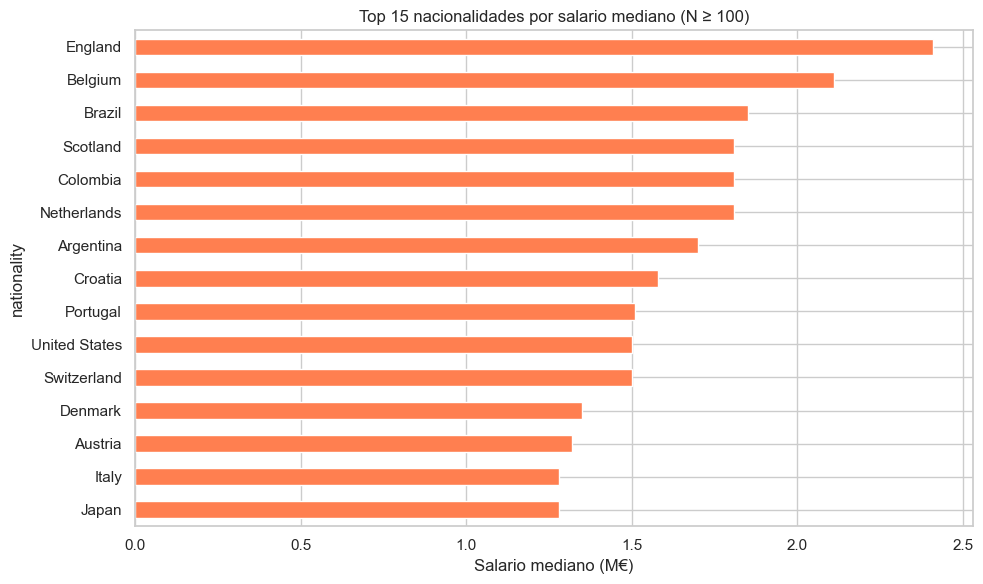

In [13]:
# Visualización
top_15_sal = nac_stats.head(15)['median_M'].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top_15_sal.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Salario mediano (M€)')
ax.set_title('Top 15 nacionalidades por salario mediano (N ≥ 100)')
plt.tight_layout()
plt.show()

**Lectura:** las nacionalidades mejor pagadas en mediana son las grandes potencias futbolísticas,
especialmente las que exportan a las ligas top como la Premier League. La nacionalidad opera aquí
como **proxy de calidad media del jugador**, ya que países con mejor formación de cantera o más
densidad de talento tienen jugadores más demandados.

**Decisión para feature engineering:** mantener solo las top-N nacionalidades como categorías
explícitas y agrupar el resto bajo "Otra". Lo razonable serán entre 10 y 20 categorías, a definir
en la fase 05.

## 6. Resumen y decisiones para feature engineering

### Nota metodológica: uso sistemático de la mediana

A lo largo de este notebook se utiliza la **mediana** (no la media) como medida de tendencia central.
Esta decisión es coherente con el carácter fuertemente asimétrico de la distribución salarial
(skewness γ₁ ≈ +6, ver notebook 04_02): en distribuciones tan sesgadas, la media está sistemáticamente
inflada por los outliers superiores y no representa al jugador típico. La mediana, al ser robusta a
valores extremos, ofrece una imagen más fiel de la tendencia central. Ésta es además la práctica
estándar en la literatura económica de salarios (INE, Eurostat, OCDE).

### Hallazgos principales

| Variable | Hallazgo |
|---|---|
| **`position`** | 4 categorías. Salario mediano: M > F > D > K. Las features predictivas varían por posición. |
| **`position` (nulos)** | 1.756 jugadores (8.6%) sin posición asignada — probablemente jugadores con muy pocos minutos. Quedarán fuera de cualquier modelo segmentado por posición. |
| **`age`** | Distribución sesgada (no simétrica): truncada a la izquierda por la edad mínima de profesionalización (~17-18 años). Mediana en 26 años. |
| **`age` × salario** | Curva de carrera con forma de campana asimétrica: subida rápida hasta los 24, plateau hasta los 32, declive marcado a partir de 33. Compatible con la **ecuación de Mincer** (1974). |
| **`position` × `age`** | Trayectorias salariales muy distintas por posición. Justifica interacciones o modelos separados. |
| **`nationality`** | 131 categorías. Las primeras **6 coinciden con las 6 ligas analizadas**. Top 10 concentra el 62.4% de los registros. |

### Decisiones que se trasladan a la fase 05

1. **`position`** → encoding *one-hot* (4 categorías). Decidir si los 1.756 nulos se descartan o se imputan a una categoría "Unknown".
2. **`age`** → mantener como variable numérica + añadir `age²` (término cuadrático de Mincer) para capturar la curvatura no lineal.
3. **`position` × `age`** → considerar interacciones, especialmente si se opta por un único modelo en lugar de modelos separados por posición.
4. **`nationality`** → reducir a top-N + "Otras". El número óptimo de N se decidirá empíricamente (probablemente entre 10 y 20).